In [1]:
# Parameters (papermill overrides these via -p DATA_DIR ... -p SEED ... -p OUT_DIR ...)
DATA_DIR = "./data"
SEED = 42
OUT_DIR = "reports"

In [2]:
# Parameters
DATA_DIR = "./data"
SEED = 42
OUT_DIR = "reports"


# 01 — Exploración inicial del corpus
**Autor:** Giuliano Crenna, Juan Ignacio Pace (UGR)
**Fecha:** 2026-09-03
**Descripción:** Conteos por fuente/clase, longitudes, % vacíos. Etapa 3 — EDA previa al modelado.


## Parámetros (papermill)
- `DATA_DIR`: ruta a `data/` (default `./data`).
- `SEED`: semilla (default 42).
- `OUT_DIR`: dónde guardar figuras y tablas (default `reports`).


In [3]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt

# `DATA_DIR`, `SEED`, `OUT_DIR` vienen de la celda parameters (papermill los sobreescribe).
# Fallback a os.environ.get por si se ejecuta fuera de papermill.
DATA_DIR = Path(os.environ.get("DATA_DIR", DATA_DIR))
SEED = int(os.environ.get("SEED", SEED))
OUT_DIR = Path(os.environ.get("OUT_DIR", OUT_DIR))
OUT_DIR.mkdir(parents=True, exist_ok=True)
(OUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)

import random
random.seed(SEED)
np.random.seed(SEED)

# Carga con fallback: processed > interim.
processed = DATA_DIR / "processed" / "corpus_v1.parquet"
if processed.exists():
    df = pd.read_parquet(processed)
    src_used = "processed/corpus_v1.parquet"
else:
    print(f"WARN: no existe {processed} — usando interim/*.parquet")
    frames = [pd.read_parquet(p) for p in (DATA_DIR / "interim").glob("*/data.parquet")]
    df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
    src_used = "interim/*/data.parquet"

print(f"origen: {src_used}")
print(f"corpus: {len(df):,} filas, {df['user_id'].nunique():,} usuarios únicos")
if df.empty:
    raise SystemExit("ERROR: no hay datos para analizar")
df.head()

origen: processed/corpus_v1.parquet
corpus: 1,047,194 filas, 317 usuarios únicos


,doc_id,user_id,source,timestamp,text_raw,text_clean,label,label_source,lang,corpus_source,is_translated
0,7106b6e90eeb40df,3f3a5f0934dcdc9b,coello_guilarte,2016-01-01T17:14:07+00:00,RT @LaChotaDeGrey: ¡Por un 2016 donde los pers...,: ¡Por un 2016 donde los personajes ficticios ...,2,crowd_annotation,es,coello_guilarte,False
1,5f2034a463403db8,3f3a5f0934dcdc9b,coello_guilarte,2016-01-01T23:06:46+00:00,RT @booksaddict97: “Nuestras vidas no solo se ...,: “Nuestras vidas no solo se miden en años. Se...,2,crowd_annotation,es,coello_guilarte,False
2,5832a2ae5ffcb564,3f3a5f0934dcdc9b,coello_guilarte,2016-01-02T17:15:36+00:00,RT @mutewords: Aunque el whatsapp no sea una p...,": Aunque el whatsapp no sea una pregunta, podé...",2,crowd_annotation,es,coello_guilarte,False
3,e797bfcb1b9452b4,3f3a5f0934dcdc9b,coello_guilarte,2016-01-03T16:18:17+00:00,RT @soyeldelfin: para tener suerte en el 2016 ...,: para tener suerte en el 2016 hay que comenza...,2,crowd_annotation,es,coello_guilarte,False
4,dfd77167aca936bd,3f3a5f0934dcdc9b,coello_guilarte,2016-01-05T10:50:38+00:00,RT @fotogramas_es: Primeras imágenes de LA CHI...,: Primeras imágenes de LA CHICA DEL TREN la ad...,2,crowd_annotation,es,coello_guilarte,False


In [4]:
# Cargar label_map desde configs (si existe).
try:
    cfg = yaml.safe_load(Path("configs/data.yaml").read_text()) if Path("configs/data.yaml").exists() else {}
    _lm = cfg.get("data", {}).get("label_map", {0: "control", 1: "moderate", 2: "depressive"})
except Exception:
    _lm = {0: "control", 1: "moderate", 2: "depressive"}
print(f"label_map = {_lm}")

# Conteos por fuente y por clase.
counts_src = df["source"].value_counts()
counts_lab = df["label"].value_counts().sort_index()
counts_src_lab = df.groupby(["source", "label"]).size().unstack(fill_value=0)

print("=== Conteos por fuente ===")
print(counts_src)
print("\n=== Conteos por label ===")
print(counts_lab)
print("\n=== Conteos por fuente × label ===")
print(counts_src_lab)

# Persistir tabla resumen.
summary = pd.DataFrame({
    "n_docs": counts_src,
    "n_users": df.groupby("source")["user_id"].nunique(),
    "n_labels": df.groupby("source")["label"].nunique(),
}).reset_index().rename(columns={"index": "source"})
summary.to_csv(OUT_DIR / "tables" / "eda_01_corpus_summary.csv", index=False)
print(f"\ntabla -> {OUT_DIR / 'tables' / 'eda_01_corpus_summary.csv'}")

label_map = {0: 'control', 1: 'moderate', 2: 'depressive'}


=== Conteos por fuente ===
source
coello_guilarte    1047194
Name: count, dtype: int64

=== Conteos por label ===
label
0    746271
2    300923
Name: count, dtype: int64

=== Conteos por fuente × label ===
label                 0       2
source                         
coello_guilarte  746271  300923



tabla -> reports\tables\eda_01_corpus_summary.csv


In [5]:
# Longitudes de texto (caracteres y tokens).
df["len_chars"] = df["text_clean"].fillna("").str.len()
df["len_tokens"] = df["text_clean"].fillna("").str.split().str.len()
desc = df[["len_chars", "len_tokens"]].describe()
print(desc)
print()
pct_empty = (df["text_clean"].fillna("").str.len() == 0).groupby(df["source"]).mean() * 100
print("% vacíos por fuente:")
print(pct_empty)
desc.to_csv(OUT_DIR / "tables" / "eda_01_lengths_describe.csv")
pct_empty.to_csv(OUT_DIR / "tables" / "eda_01_pct_empty_by_source.csv", header=["pct_empty"])

          len_chars    len_tokens
count  1.047194e+06  1.047194e+06
mean   5.942405e+01  1.127724e+01
std    3.729112e+01  6.969094e+00
min    0.000000e+00  0.000000e+00
25%    2.900000e+01  6.000000e+00
50%    5.200000e+01  1.000000e+01
75%    9.000000e+01  1.700000e+01
max    4.680000e+02  6.100000e+01



% vacíos por fuente:
source
coello_guilarte    1.482342
Name: text_clean, dtype: float64


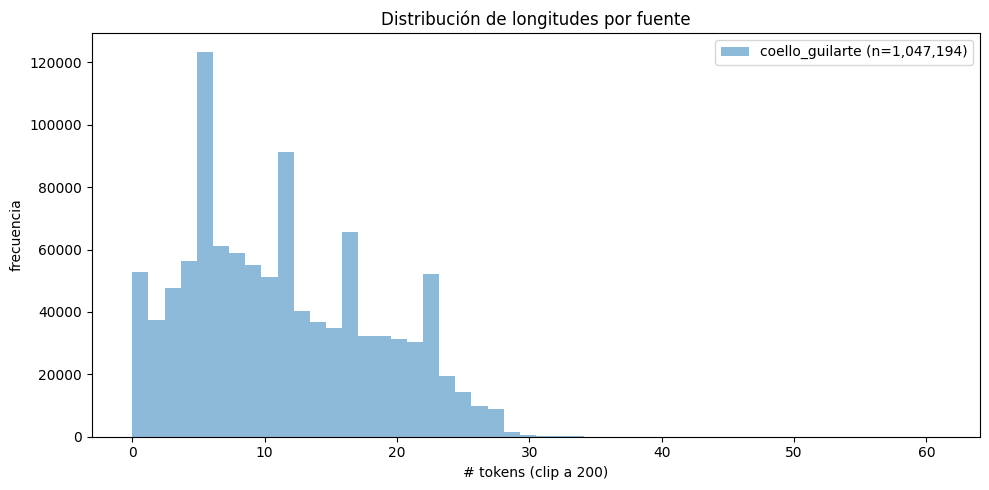

figura -> reports\figures\eda_01_longitudes_por_fuente.png


In [6]:
# Histograma de longitudes por fuente.
fig, ax = plt.subplots(figsize=(10, 5))
for src, sub in df.groupby("source"):
    ax.hist(sub["len_tokens"].clip(upper=200), bins=50, alpha=0.5, label=f"{src} (n={len(sub):,})")
ax.set_xlabel("# tokens (clip a 200)")
ax.set_ylabel("frecuencia")
ax.set_title("Distribución de longitudes por fuente")
ax.legend()
plt.tight_layout()
out = OUT_DIR / "figures" / "eda_01_longitudes_por_fuente.png"
plt.savefig(out, dpi=120)
plt.show()
print(f"figura -> {out}")

In [7]:
# Conclusiones dinámicas: computadas al ejecutar.
from IPython.display import Markdown, display

_md = f"""
## Conclusiones

**Hallazgos cuantitativos** (ejecutado {pd.Timestamp.utcnow().strftime("%Y-%m-%d %H:%M UTC")}):

- **Volumen**: {len(df):,} documentos / {df["user_id"].nunique():,} usuarios únicos / {df["source"].nunique()} fuente(s).
- **Balance de clases**: """ + " ".join(
    [f"label {lab} ({_lm.get(lab, '?')}) = {int(count):,} ({100*count/len(df):.1f}%); "
     for lab, count in df["label"].value_counts().sort_index().items()]
) + f"""
- **Calidad del texto**:
  - {((df["text_clean"].fillna("").str.len() == 0).mean()*100):.2f}% de tweets quedaron vacíos tras anonimización.
  - Media de tokens por tweet: {df["len_tokens"].mean():.2f}; mediana: {df["len_tokens"].median():.2f}; p75: {df["len_tokens"].quantile(0.75):.2f}.
- **Notas metodológicas**: anonimización previa (URLs, menciones, emails, teléfonos, hashtags, prefijo RT). Sin NER en v1.
"""
display(Markdown(_md))



## Conclusiones

**Hallazgos cuantitativos** (ejecutado 2026-09-03 20:36 UTC):

- **Volumen**: 1,047,194 documentos / 317 usuarios únicos / 1 fuente(s).
- **Balance de clases**: label 0 (control) = 746,271 (71.3%);  label 2 (depressive) = 300,923 (28.7%); 
- **Calidad del texto**:
  - 1.48% de tweets quedaron vacíos tras anonimización.
  - Media de tokens por tweet: 11.28; mediana: 10.00; p75: 17.00.
- **Notas metodológicas**: anonimización previa (URLs, menciones, emails, teléfonos, hashtags, prefijo RT). Sin NER en v1.
